# Notebook 13: LSTM Gentrification Prediction Prototype

**Objective:** Build a PyTorch LSTM that predicts gentrification class (0/1/2) per neighborhood cluster from temporal CVR business data.  
Spatial-join 341K business points to 1,421 clusters, aggregate industry counts per 5-year window (6 time steps), learn NACE embeddings, and train an LSTM classifier — directly comparable with the XGBoost baseline (Notebook 05).

**Phases:**
1. Data Pipeline & Storage
2. Feature Engineering & Embeddings
3. PyTorch LSTM Model & Training

## Phase 1 — Data Pipeline

In [1]:
# Cell 1: Imports & config
import os, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore", category=FutureWarning)

# ── Paths (relative from notebooks/) ──
CVR_GEO_PATH       = Path("../data/processed/cvr/CVR_geo_temporal.geojson")
CLUSTER_SHP_PATH   = Path("../data/raw/neighborhood_shapefile/Nabolag_cph_fre_new.shp")
STA_DATA_PATH      = Path("../data/interim/STA_data.csv")
PARQUET_OUT_PATH   = Path("../data/processed/cvr/cvr_cluster_temporal_counts.parquet")
MODEL_OUT_PATH     = Path("../results/models/lstm_gentrification.pt")
PRED_OUT_PATH      = Path("../results/models/lstm_predictions.csv")

# ── Temporal periods (matching XGBoost notebook 05) ──
PERIODS = [
    (1990, 1995),
    (1995, 2000),
    (2000, 2005),
    (2005, 2010),
    (2010, 2015),
    (2015, 2020),
]
NUM_PERIODS = len(PERIODS)

# ── Reproducibility ──
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | Device: {DEVICE}")

PyTorch 2.11.0+cpu | Device: cpu


In [2]:
# Cell 2: Load CVR GeoJSON, parse dates, reproject to EPSG:25832
print("Loading CVR_geo_temporal.geojson ...")
cvr_gdf = gpd.read_file(CVR_GEO_PATH)
print(f"Loaded {len(cvr_gdf):,} business features | CRS: {cvr_gdf.crs}")

# Parse dates
for col in ["produktionsenhedStartdato", "produktionsenhedOphoersdato",
            "virksomhedStartdato", "virksomhedOphoersdato"]:
    if col in cvr_gdf.columns:
        cvr_gdf[col] = pd.to_datetime(cvr_gdf[col], errors="coerce")

# Use produktionsenhed dates as primary; fall back to virksomhed dates
cvr_gdf["start_date"] = cvr_gdf["produktionsenhedStartdato"].fillna(
    cvr_gdf["virksomhedStartdato"]
)
cvr_gdf["end_date"] = cvr_gdf["produktionsenhedOphoersdato"].fillna(
    cvr_gdf["virksomhedOphoersdato"]
)

# Reproject WGS84 → EPSG:25832
if cvr_gdf.crs is None or cvr_gdf.crs.to_epsg() != 25832:
    cvr_gdf = cvr_gdf.to_crs(epsg=25832)
    print(f"Reprojected to EPSG:25832")

# Drop rows without geometry
before = len(cvr_gdf)
cvr_gdf = cvr_gdf[cvr_gdf.geometry.notna()].copy()
print(f"Dropped {before - len(cvr_gdf):,} rows with null geometry → {len(cvr_gdf):,} remaining")

# Extract 2-digit NACE prefix
cvr_gdf["nace2"] = cvr_gdf["branche_kode"].astype(str).str[:2]
print(f"Unique 2-digit NACE codes: {cvr_gdf['nace2'].nunique()}")
cvr_gdf.head(3)

Loading CVR_geo_temporal.geojson ...


c:\Users\jonas\Desktop\7_semester\Projekt\Gentrification_model\.venv\Lib\site-packages\geopandas\io\file.py:576: UserWarning: Error parsing datetimes, original strings are returned: Out of bounds nanosecond timestamp: 0082-11-01, at position 7896. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)
c:\Users\jonas\Desktop\7_semester\Projekt\Gentrification_model\.venv\Lib\site-packages\geopandas\io\file.py:576: UserWarning: Error parsing datetimes, original strings are returned: Out of bounds nanosecond timestamp: 0082-11-01, at position 3761. You might want to try:
    - passing `format` if your strings have a consistent format;
   

Loaded 341,781 business features | CRS: EPSG:4326
Reprojected to EPSG:25832
Dropped 0 rows with null geometry → 341,781 remaining
Unique 2-digit NACE codes: 92


,CVRNummer,navn,virksomhedStartdato,virksomhedOphoersdato,branche_kode,branche_navn,CVREnhedsId,Adresse,pNummer,tilknyttetVirksomhedsCVRNummer,produktionsenhedStartdato,produktionsenhedOphoersdato,geometry,start_date,end_date,nace2
0,13412731,CARNEGIE ASSET ADMINISTRATION A/S,1989-08-01,2019-06-11,661900,Andre hjælpetjenester i forbindelse med finans...,4002799827,d8f92e9d-db74-45b0-89b2-973686e16809,1000558874,13412731,1989-08-01,2019-06-11,POINT (725925.52 6178533.39),1989-08-01,2019-06-11,66
1,81090416,"ERIK CHRISTENSEN & SØN, BIRKERØD A/S",1977-11-04,NaT,511100,"Agenturhandel med råvarer til landbruget, land...",4003147554,c44181eb-7625-4844-93ce-6fde4d89e444,1002971450,81090416,1991-01-01,2010-11-25,POINT (724033.54 6174859),1991-01-01,2010-11-25,51
2,62764228,DSR FORLAG-BOGHANDEL,1999-10-16,2005-05-02,222210,Bogtrykkerier og offsettrykkerier,4002281296,12bfb2fa-9d2c-440e-b0d9-9122e4aca5c3,1003151135,62764228,1979-10-22,2012-08-31,POINT (722696.6 6175998.32),1979-10-22,2012-08-31,22


In [5]:
# Cell 3: Spatial join — assign cluster_id to each business
print("Loading cluster polygons ...")
clusters = gpd.read_file(CLUSTER_SHP_PATH)
print(f"Loaded {len(clusters):,} cluster polygons | CRS: {clusters.crs}")
print(f"Columns: {list(clusters.columns)}")

# Pick the right join key (avoid duplicate after rename)
if "munic_clus" in clusters.columns:
    join_key = "munic_clus"
elif "cluster_id" in clusters.columns:
    join_key = "cluster_id"
else:
    raise KeyError("No munic_clus or cluster_id column found in shapefile")

# Keep only the join key + geometry, then rename to cluster_id
clusters_slim = clusters[[join_key, "geometry"]].copy()
clusters_slim = clusters_slim.rename(columns={join_key: "cluster_id"})

# Spatial join (inner keeps only businesses inside a polygon)
print("Running spatial join ...")
cvr_joined = gpd.sjoin(cvr_gdf, clusters_slim, how="inner", predicate="within")

match_rate = len(cvr_joined) / len(cvr_gdf) * 100
print(f"Matched {len(cvr_joined):,} / {len(cvr_gdf):,} businesses ({match_rate:.1f}%)")
print(f"Businesses assigned to {cvr_joined['cluster_id'].nunique()} unique clusters")

Loading cluster polygons ...
Loaded 1,421 cluster polygons | CRS: EPSG:25832
Columns: ['fid_1', 'munic_code', 'id_munic', 'munic_clus', 'Shape_Leng', 'Shape_Area', 'cluster_id', 'geometry']
Running spatial join ...
Matched 290,735 / 341,781 businesses (85.1%)
Businesses assigned to 1421 unique clusters


In [6]:
# Cell 4: Temporal bucketing — determine which periods each business was active
def assign_periods(row):
    """Return list of period indices where the business was active."""
    start = row["start_date"]
    end   = row["end_date"]
    start_year = start.year if pd.notna(start) else 1900
    end_year   = end.year   if pd.notna(end)   else 2026  # still active
    active = []
    for i, (p_start, p_end) in enumerate(PERIODS):
        if start_year < p_end and end_year >= p_start:
            active.append(i)
    return active

print("Assigning businesses to 5-year periods ...")
cvr_joined["active_periods"] = cvr_joined.apply(assign_periods, axis=1)

# Explode so each row = one business × one period
cvr_exploded = cvr_joined.explode("active_periods")
cvr_exploded = cvr_exploded.dropna(subset=["active_periods"])
cvr_exploded["period_idx"] = cvr_exploded["active_periods"].astype(int)

print(f"Exploded to {len(cvr_exploded):,} business-period rows")
print(f"Period distribution:")
for i, (ps, pe) in enumerate(PERIODS):
    n = (cvr_exploded["period_idx"] == i).sum()
    print(f"  {ps}-{pe}: {n:,} active businesses")

Assigning businesses to 5-year periods ...
Exploded to 428,823 business-period rows
Period distribution:
  1990-1995: 20,372 active businesses
  1995-2000: 35,487 active businesses
  2000-2005: 56,246 active businesses
  2005-2010: 71,815 active businesses
  2010-2015: 98,096 active businesses
  2015-2020: 146,807 active businesses


In [7]:
# Cell 5: Aggregate — count businesses per (cluster_id, period, nace2)
print("Aggregating business counts per cluster × period × NACE sector ...")
agg = (
    cvr_exploded
    .groupby(["cluster_id", "period_idx", "nace2"])
    .size()
    .reset_index(name="count")
)

# Pivot: rows = (cluster_id, period_idx), columns = nace2 sectors
pivot = agg.pivot_table(
    index=["cluster_id", "period_idx"],
    columns="nace2",
    values="count",
    fill_value=0,
).reset_index()

# Flatten column names
nace_cols = [c for c in pivot.columns if c not in ("cluster_id", "period_idx")]
pivot.columns.name = None

# Add total business count per cluster-period
pivot["total_businesses"] = pivot[nace_cols].sum(axis=1)

print(f"Aggregated shape: {pivot.shape}")
print(f"NACE sector columns: {len(nace_cols)}")
print(f"Unique clusters in aggregation: {pivot['cluster_id'].nunique()}")
pivot.head()

Aggregating business counts per cluster × period × NACE sector ...
Aggregated shape: (8454, 94)
NACE sector columns: 91
Unique clusters in aggregation: 1421


,cluster_id,period_idx,01,02,03,05,06,08,09,10,...,92,93,94,95,96,97,98,99,No,total_businesses
0,101_1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
1,101_1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,8.0
2,101_1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,7.0
3,101_1,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,2.0,1.0,0.0,19.0
4,101_1,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,3.0,0.0,1.0,0.0,2.0,3.0,0.0,35.0


In [8]:
# Cell 6: Save to Parquet + verify coverage
PARQUET_OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
pivot.to_parquet(PARQUET_OUT_PATH, index=False)
print(f"Saved aggregated data to {PARQUET_OUT_PATH} ({PARQUET_OUT_PATH.stat().st_size/1024:.0f} KB)")

# Load target labels to check coverage
sta = pd.read_csv(STA_DATA_PATH)
target_clusters = set(sta["cluster_id"].astype(str))
agg_clusters = set(pivot["cluster_id"].astype(str))

covered = target_clusters & agg_clusters
missing = target_clusters - agg_clusters
print(f"\nTarget clusters (STA_data): {len(target_clusters)}")
print(f"Clusters with CVR data:     {len(agg_clusters)}")
print(f"Overlap:                    {len(covered)} ({len(covered)/len(target_clusters)*100:.1f}%)")
if missing:
    print(f"Missing clusters (no CVR data): {len(missing)}")

# Class distribution in target
print(f"\nTarget class distribution (mean_sd_class_idx):")
print(sta["mean_sd_class_idx"].value_counts().sort_index())

Saved aggregated data to ..\data\processed\cvr\cvr_cluster_temporal_counts.parquet (249 KB)

Target clusters (STA_data): 1421
Clusters with CVR data:     1421
Overlap:                    1421 (100.0%)

Target class distribution (mean_sd_class_idx):
mean_sd_class_idx
0    253
1    911
2    257
Name: count, dtype: int64


## Phase 2 — Feature Engineering & Dataset

In [9]:
# Cell 7: Build sequence tensors
# Reload from Parquet (allows skipping Phase 1 on re-runs)
pivot = pd.read_parquet(PARQUET_OUT_PATH)
sta = pd.read_csv(STA_DATA_PATH)

# Identify feature columns (all NACE sectors + total)
meta_cols = ["cluster_id", "period_idx"]
feature_cols = [c for c in pivot.columns if c not in meta_cols]
print(f"Feature columns ({len(feature_cols)}): {feature_cols[:10]} ...")

# Build NACE vocabulary for embedding
nace_cols = [c for c in feature_cols if c != "total_businesses"]
nace2idx = {code: i for i, code in enumerate(sorted(nace_cols))}
idx2nace = {i: code for code, i in nace2idx.items()}
NUM_NACE = len(nace2idx)
print(f"NACE vocabulary: {NUM_NACE} unique 2-digit codes")

# Ensure all clusters have all 6 periods (fill missing periods with zeros)
all_clusters = sorted(pivot["cluster_id"].unique())
all_periods = list(range(NUM_PERIODS))

full_index = pd.MultiIndex.from_product(
    [all_clusters, all_periods], names=["cluster_id", "period_idx"]
)
pivot_full = (
    pivot.set_index(["cluster_id", "period_idx"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)
print(f"Full matrix: {pivot_full.shape[0]} rows = {len(all_clusters)} clusters × {NUM_PERIODS} periods")

Feature columns (92): ['01', '02', '03', '05', '06', '08', '09', '10', '11', '12'] ...
NACE vocabulary: 91 unique 2-digit codes
Full matrix: 8526 rows = 1421 clusters × 6 periods


In [10]:
# Cell 8: Prepare target labels + train/val/test split
# Align targets with our cluster set
sta["cluster_id"] = sta["cluster_id"].astype(str)
pivot_full["cluster_id"] = pivot_full["cluster_id"].astype(str)

# Only keep clusters that exist in both datasets
valid_clusters = sorted(
    set(pivot_full["cluster_id"].unique()) & set(sta["cluster_id"].unique())
)
print(f"Clusters with both CVR data and target label: {len(valid_clusters)}")

# Build target series indexed by cluster_id
target_map = sta.set_index("cluster_id")["mean_sd_class_idx"].to_dict()
y_all = np.array([int(target_map[c]) for c in valid_clusters])

# Stratified split: 60% train / 20% val / 20% test (matching XGBoost conventions)
train_clusters, temp_clusters, y_train_lbl, y_temp_lbl = train_test_split(
    valid_clusters, y_all, test_size=0.4, random_state=RANDOM_STATE, stratify=y_all
)
val_clusters, test_clusters, y_val_lbl, y_test_lbl = train_test_split(
    temp_clusters, y_temp_lbl, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp_lbl
)

print(f"Train: {len(train_clusters)} | Val: {len(val_clusters)} | Test: {len(test_clusters)}")
for name, labels in [("Train", y_train_lbl), ("Val", y_val_lbl), ("Test", y_test_lbl)]:
    counts = np.bincount(labels, minlength=3)
    print(f"  {name} class distribution: {dict(enumerate(counts))}")

Clusters with both CVR data and target label: 1421
Train: 852 | Val: 284 | Test: 285
  Train class distribution: {0: np.int64(152), 1: np.int64(546), 2: np.int64(154)}
  Val class distribution: {0: np.int64(51), 1: np.int64(182), 2: np.int64(51)}
  Test class distribution: {0: np.int64(50), 1: np.int64(183), 2: np.int64(52)}


In [11]:
# Cell 9: Normalize features (fit on train only) & build tensors
scaler = MinMaxScaler()

# Extract feature matrices per split
def build_sequences(cluster_list, fit_scaler=False):
    """Build (N, T, F) tensor for a list of clusters. T=6 periods, F=features."""
    sequences = []
    for cid in cluster_list:
        mask = pivot_full["cluster_id"] == cid
        cluster_data = pivot_full.loc[mask].sort_values("period_idx")
        feat_matrix = cluster_data[feature_cols].values  # (6, F)
        sequences.append(feat_matrix)
    arr = np.stack(sequences)  # (N, 6, F)
    
    # Normalize: reshape to 2D, scale, reshape back
    N, T, F = arr.shape
    flat = arr.reshape(-1, F)
    if fit_scaler:
        flat = scaler.fit_transform(flat)
    else:
        flat = scaler.transform(flat)
    return torch.tensor(flat.reshape(N, T, F), dtype=torch.float32)

X_train = build_sequences(train_clusters, fit_scaler=True)
X_val   = build_sequences(val_clusters)
X_test  = build_sequences(test_clusters)

y_train = torch.tensor(y_train_lbl, dtype=torch.long)
y_val   = torch.tensor(y_val_lbl, dtype=torch.long)
y_test  = torch.tensor(y_test_lbl, dtype=torch.long)

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}   | y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")
print(f"Feature dim: {X_train.shape[2]}")

X_train: torch.Size([852, 6, 92]) | y_train: torch.Size([852])
X_val:   torch.Size([284, 6, 92])   | y_val:   torch.Size([284])
X_test:  torch.Size([285, 6, 92])  | y_test:  torch.Size([285])
Feature dim: 92


In [12]:
# Cell 10: PyTorch Dataset & DataLoaders
class GentrificationDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 64

train_ds = GentrificationDataset(X_train, y_train)
val_ds   = GentrificationDataset(X_val, y_val)
test_ds  = GentrificationDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

# Compute class weights (inverse frequency) for loss function
class_counts = np.bincount(y_train.numpy(), minlength=3).astype(float)
class_weights = 1.0 / class_counts
class_weights /= class_weights.sum()  # normalize
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print(f"Class weights: {class_weights}")
print(f"Batches — train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")

Class weights: tensor([0.4414, 0.1229, 0.4357])
Batches — train: 14 | val: 5 | test: 5


## Phase 3 — LSTM Model & Training

In [16]:
# Cell 11: Model definition
class GentrificationLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2,
                 num_nace=0, embed_dim=16, num_classes=3, dropout=0.3):
        super().__init__()
        self.num_nace = num_nace
        self.embed_dim = embed_dim
        
        # NACE embedding: one embedding vector per 2-digit sector,
        # weighted by the sector count at each timestep
        if num_nace > 0:
            self.nace_embedding = nn.Embedding(num_nace, embed_dim)
            # Replace num_nace count columns with embed_dim-sized vector
            lstm_input = (input_dim - num_nace) + embed_dim
        else:
            lstm_input = input_dim
        
        self.lstm = nn.LSTM(
            input_size=lstm_input,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)
    
    def forward(self, x):
        # x shape: (batch, seq_len=6, input_dim)
        if self.num_nace > 0:
            # First num_nace columns are NACE sector counts
            nace_counts = x[:, :, :self.num_nace]  # (B, T, num_nace)
            other_feats = x[:, :, self.num_nace:]  # (B, T, remaining)
            
            # Weighted sum of embeddings: sum(count_i * embed_i) per timestep
            nace_indices = torch.arange(self.num_nace, device=x.device)  # (num_nace,)
            all_embeds = self.nace_embedding(nace_indices)  # (num_nace, embed_dim)
            # nace_counts: (B, T, num_nace) @ all_embeds: (num_nace, embed_dim)
            weighted_embed = torch.matmul(nace_counts, all_embeds)  # (B, T, embed_dim)
            
            x = torch.cat([weighted_embed, other_feats], dim=-1)  # (B, T, embed_dim + remaining)
        
        lstm_out, (h_n, _) = self.lstm(x)  # h_n: (num_layers, B, hidden)
        last_hidden = h_n[-1]  # (B, hidden)
        out = self.dropout(last_hidden)
        logits = self.fc(out)  # (B, num_classes)
        return logits

# Instantiate
INPUT_DIM = X_train.shape[2]  # total feature columns
HIDDEN_DIM = 128
NUM_LAYERS = 2
EMBED_DIM = 16
DROPOUT = 0.3

model = GentrificationLSTM(
    input_dim=INPUT_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_nace=NUM_NACE,
    embed_dim=EMBED_DIM,
    num_classes=3,
    dropout=DROPOUT,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(model)

Model parameters: 209,203
GentrificationLSTM(
  (nace_embedding): Embedding(91, 16)
  (lstm): LSTM(17, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)


In [17]:
# Cell 12: Training loop with early stopping
LR = 1e-3
EPOCHS = 50
PATIENCE = 10

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_loss = float("inf")
patience_counter = 0
best_state = None

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(y_batch)
        correct += (logits.argmax(1) == y_batch).sum().item()
        total += len(y_batch)
    train_loss = running_loss / total
    train_acc  = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ── Validate ──
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            running_loss += loss.item() * len(y_batch)
            correct += (logits.argmax(1) == y_batch).sum().item()
            total += len(y_batch)
    val_loss = running_loss / total
    val_acc  = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # ── Early stopping ──
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1

    if epoch % 5 == 0 or patience_counter == PATIENCE:
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Train loss: {train_loss:.4f} acc: {train_acc:.3f} | "
              f"Val loss: {val_loss:.4f} acc: {val_acc:.3f} | "
              f"Patience: {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

# Restore best model
if best_state is not None:
    model.load_state_dict(best_state)
    model.to(DEVICE)
print(f"\nBest val loss: {best_val_loss:.4f}")

Epoch   5/50 | Train loss: 1.0429 acc: 0.296 | Val loss: 1.0383 acc: 0.345 | Patience: 0/10
Epoch  10/50 | Train loss: 0.9476 acc: 0.419 | Val loss: 1.0260 acc: 0.384 | Patience: 2/10
Epoch  15/50 | Train loss: 0.8463 acc: 0.508 | Val loss: 1.0594 acc: 0.437 | Patience: 7/10
Epoch  18/50 | Train loss: 0.8234 acc: 0.522 | Val loss: 1.0538 acc: 0.447 | Patience: 10/10

Early stopping at epoch 18

Best val loss: 1.0242


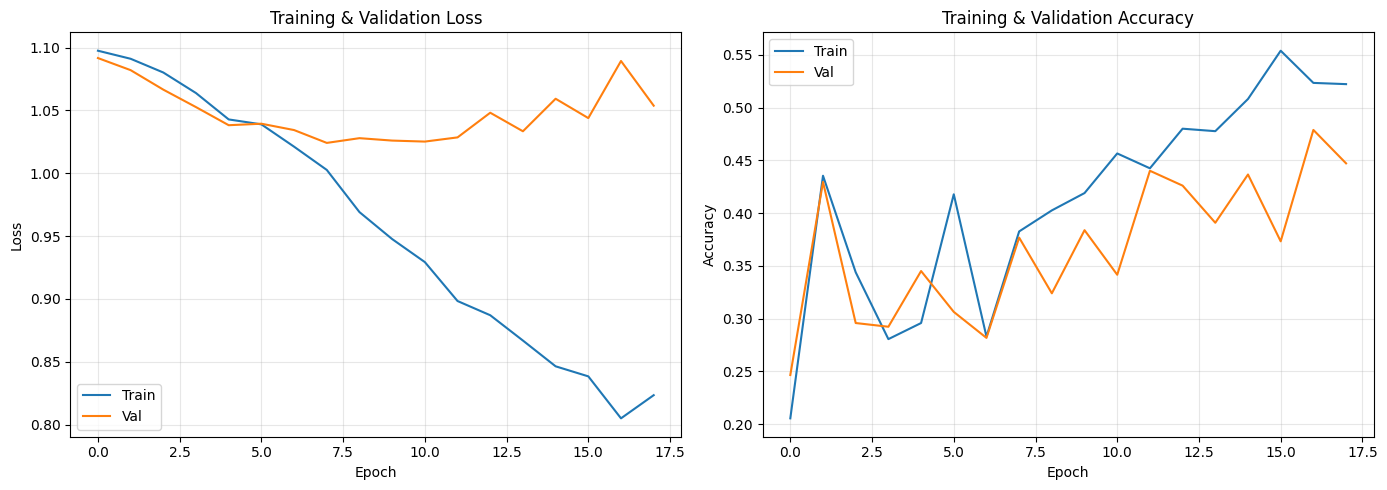

In [18]:
# Cell 13: Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label="Train")
ax1.plot(val_losses, label="Val")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training & Validation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, label="Train")
ax2.plot(val_accs, label="Val")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Training & Validation Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

TEST SET EVALUATION
Accuracy: 0.3649

              precision    recall  f1-score   support

     Class 0       0.25      0.60      0.35        50
     Class 1       0.78      0.21      0.33       183
     Class 2       0.31      0.69      0.43        52

    accuracy                           0.36       285
   macro avg       0.45      0.50      0.37       285
weighted avg       0.60      0.36      0.35       285



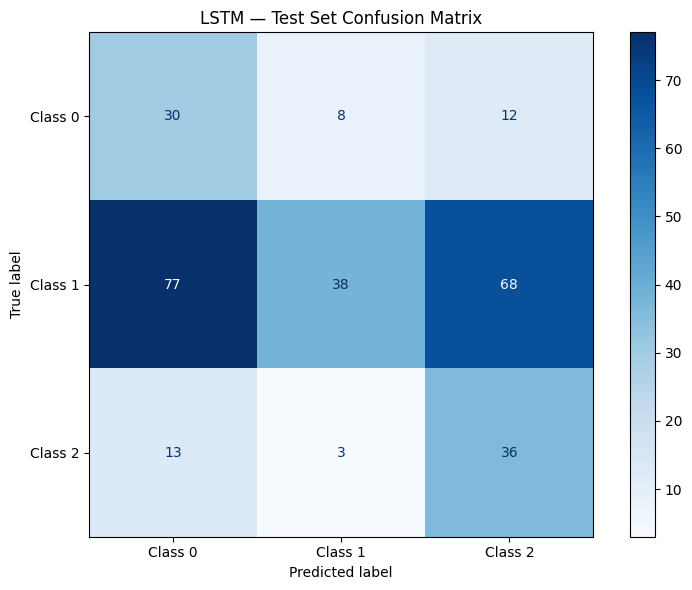

In [19]:
# Cell 14: Evaluate on test set
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        logits = model(X_batch)
        preds = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print("=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=["Class 0", "Class 1", "Class 2"]))

# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Class 0", "Class 1", "Class 2"])
disp.plot(ax=ax, cmap="Blues")
ax.set_title("LSTM — Test Set Confusion Matrix")
plt.tight_layout()
plt.show()

Top 15 NACE sectors by embedding magnitude:
   1. NACE 46 — norm: 5.969
   2. NACE 17 — norm: 5.385
   3. NACE 69 — norm: 5.164
   4. NACE 19 — norm: 5.160
   5. NACE 98 — norm: 5.142
   6. NACE 51 — norm: 5.052
   7. NACE 93 — norm: 5.026
   8. NACE 65 — norm: 4.865
   9. NACE 16 — norm: 4.837
  10. NACE 62 — norm: 4.817
  11. NACE 18 — norm: 4.799
  12. NACE 86 — norm: 4.796
  13. NACE 09 — norm: 4.753
  14. NACE 39 — norm: 4.737
  15. NACE 90 — norm: 4.690


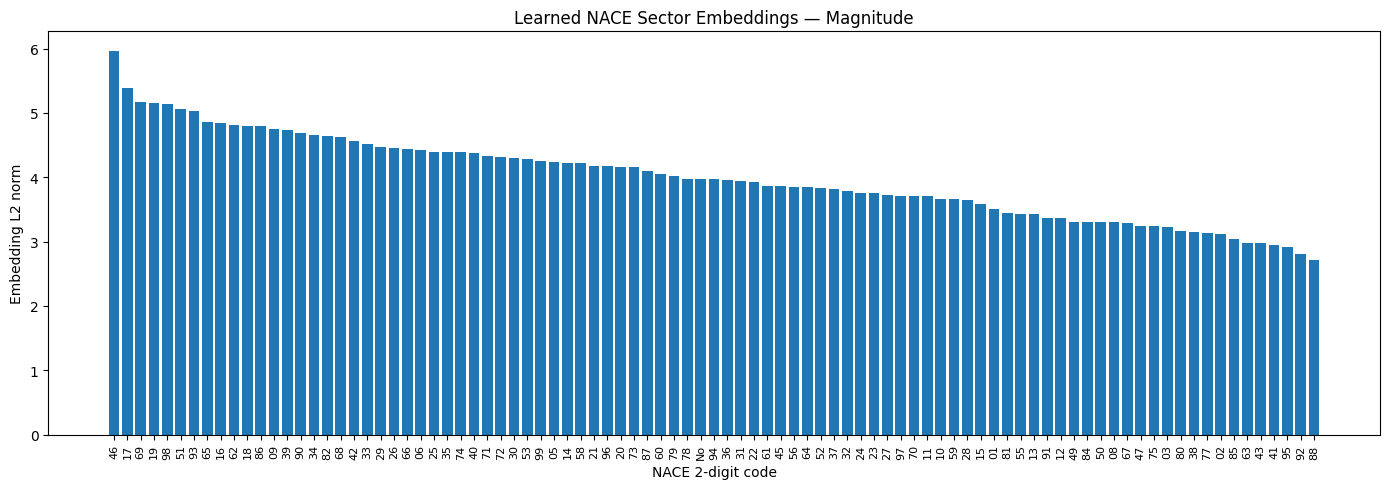

In [20]:
# Cell 15: NACE embedding analysis — which sectors matter most?
if hasattr(model, "nace_embedding"):
    with torch.no_grad():
        embeds = model.nace_embedding.weight.cpu().numpy()  # (num_nace, embed_dim)
    
    # Norm of each embedding = proxy for importance
    norms = np.linalg.norm(embeds, axis=1)
    order = np.argsort(norms)[::-1]
    
    print("Top 15 NACE sectors by embedding magnitude:")
    for rank, idx in enumerate(order[:15], 1):
        code = idx2nace[idx]
        print(f"  {rank:2d}. NACE {code} — norm: {norms[idx]:.3f}")
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 5))
    codes = [idx2nace[i] for i in order]
    ax.bar(range(len(norms)), norms[order])
    ax.set_xticks(range(len(norms)))
    ax.set_xticklabels(codes, rotation=90, fontsize=8)
    ax.set_xlabel("NACE 2-digit code")
    ax.set_ylabel("Embedding L2 norm")
    ax.set_title("Learned NACE Sector Embeddings — Magnitude")
    plt.tight_layout()
    plt.show()

In [21]:
# Cell 16: Save model & predictions
MODEL_OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save({
    "model_state_dict": model.state_dict(),
    "nace2idx": nace2idx,
    "feature_cols": feature_cols,
    "scaler_min": scaler.data_min_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
    "config": {
        "input_dim": INPUT_DIM,
        "hidden_dim": HIDDEN_DIM,
        "num_layers": NUM_LAYERS,
        "num_nace": NUM_NACE,
        "embed_dim": EMBED_DIM,
        "dropout": DROPOUT,
    },
}, MODEL_OUT_PATH)
print(f"Model saved to {MODEL_OUT_PATH}")

# Save predictions for all clusters (train + val + test)
all_cluster_preds = []
model.eval()
with torch.no_grad():
    for split_name, clusters_list in [("train", train_clusters),
                                       ("val", val_clusters),
                                       ("test", test_clusters)]:
        X_split = build_sequences(clusters_list)
        logits = model(X_split.to(DEVICE))
        preds = logits.argmax(1).cpu().numpy()
        for cid, pred in zip(clusters_list, preds):
            all_cluster_preds.append({
                "cluster_id": cid,
                "prediction": int(pred),
                "actual": int(target_map[cid]),
                "split": split_name,
            })

pred_df = pd.DataFrame(all_cluster_preds)
pred_df.to_csv(PRED_OUT_PATH, index=False)
print(f"Predictions saved to {PRED_OUT_PATH} ({len(pred_df)} clusters)")
print(f"\nOverall accuracy: {(pred_df['prediction'] == pred_df['actual']).mean():.4f}")
pred_df.head(10)

Model saved to ..\results\models\lstm_gentrification.pt
Predictions saved to ..\results\models\lstm_predictions.csv (1421 clusters)

Overall accuracy: 0.3786


,cluster_id,prediction,actual,split
0,101_68,0,2,train
1,101_558,2,1,train
2,101_621,2,0,train
3,147_150,0,1,train
4,101_185,0,1,train
5,147_105,0,1,train
6,101_456,1,1,train
7,101_713,0,1,train
8,101_71,2,1,train
9,101_1001,2,2,train
